# Import Libaries

In [133]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# 0. Load data

In [134]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "saurabhbadole/bank-customer-churn-prediction-dataset",
    output_dir="data"
)

DATA_DIR = Path(path)
DATASET_FILE = DATA_DIR / "Churn_Modelling.csv"

print("Path to dataset files:", DATASET_FILE)

Path to dataset files: data\Churn_Modelling.csv


# 1. Data inspection

In [135]:
df = pd.read_csv(DATASET_FILE)

print("Data shape:", df.shape)
print()
print(df.head())

Data shape: (10000, 14)

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.6

### Info
The dataset contains 10,000 customers and 14 columns. It includes numerical and categorical features describing customer characteristics and banking activity. The target variable is `Exited`, which indicates whether a customer left the bank. Some columns, such as `RowNumber` and `CustomerId`, are identifiers and will be removed during preprocessing.

In [136]:
print("Columns information (null values and dtypes):")
print(df.info())
print()
print(df[["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember"]].describe())

Columns information (null values and dtypes):
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None

        CreditScore           Age        Tenure        Ba

### Info
The dataset does not contain any null values. There are several numerical features, such as `Balance`, `CreditScore`, `Age`, and `EstimatedSalary`. The features have different ranges, so some of them may require standardization before training certain machine learning models. We will also check for potential outliers during the data analysis.

# 2. Evaluate data analysis

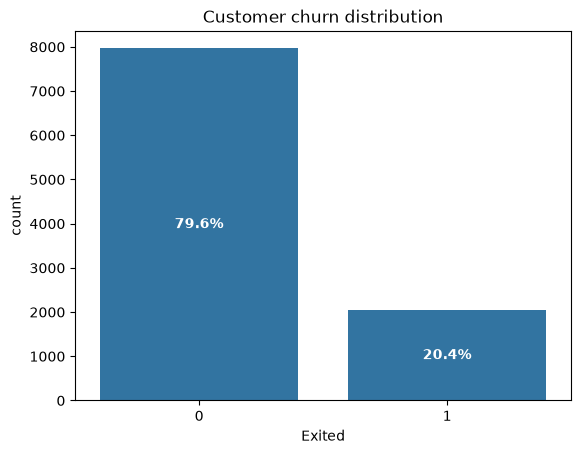

In [137]:
ax = sns.countplot(
    df,
    x="Exited"
)

total = len(df)

for container in ax.containers:

    labels= [
        f"{(bar.get_height() / total) * 100:.1f}%" 
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold"
    )
    

plt.title("Customer churn distribution")
plt.show()

### Observation
As we can see, roughly **20%** of customers leave the bank, while approximately **80%** remain.

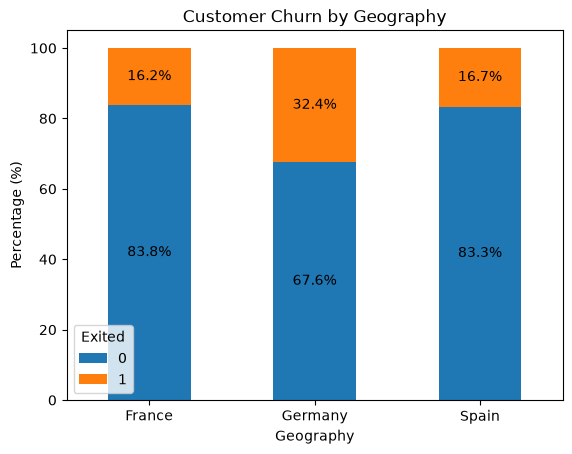

In [138]:
geo_churn = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100

ax = geo_churn.plot(
    kind="bar",
    stacked=True
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 5 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center"
    )

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Percentage (%)")
plt.legend(title="Exited")
plt.xticks(rotation=0)

plt.show()

### Observation
There is a significant difference in churn rates between Germany and the other countries. Around **32.5%** of German customers exited the bank, compared to approximately **16.5%** of customers from France and Spain.

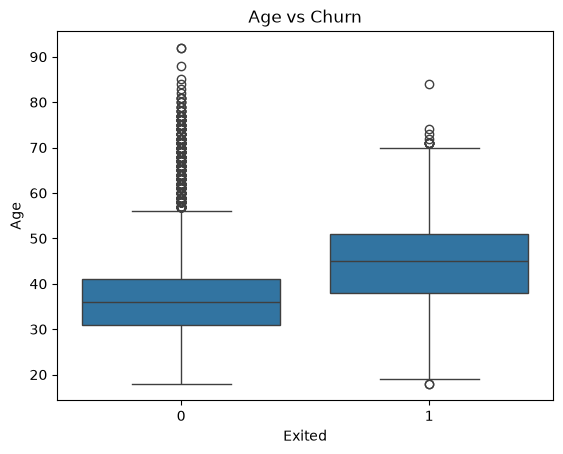

In [139]:
sns.boxplot(data=df, x="Exited", y="Age")
plt.title("Age vs Churn")
plt.show()

### Observation
Customers who exited the bank tend to be older than customers who stayed. The median age is noticeably higher for customers who churned, suggesting that age may be an important factor related to customer churn.

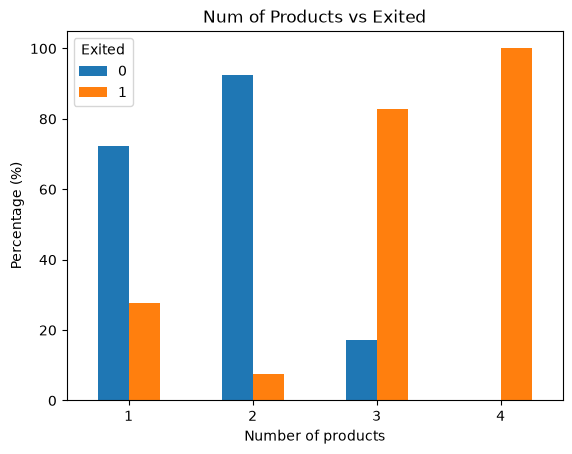

In [140]:
product_churn = pd.crosstab(
    df["NumOfProducts"],
    df["Exited"],
    normalize="index"
) * 100

ax = product_churn.plot(
    kind="bar"
)

plt.xlabel("Number of products")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.title("Num of Products vs Exited")
plt.show()

### Observation
Customers with **3** or **4** products have a significantly higher churn rate than customers with 1 or 2 products. In contrast, customers with **2** product have the lowest churn rate.

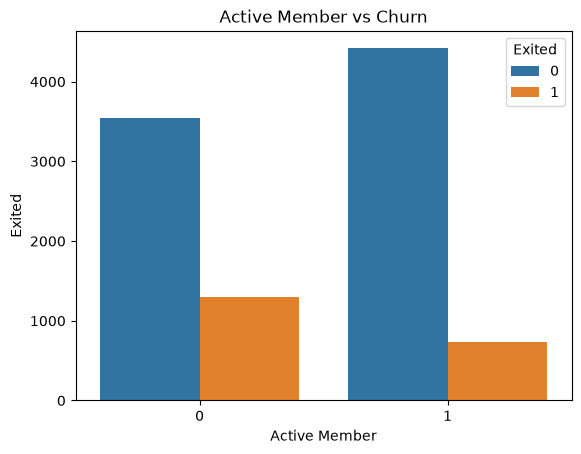

In [141]:
sns.countplot(data=df, x="IsActiveMember", hue="Exited")
plt.title("Active Member vs Churn")
plt.xlabel("Active Member")
plt.ylabel("Exited")
plt.show()

### Observation
Active members have a lower churn rate compared to inactive members. This suggests that customers who actively use the bank's services are less likely to leave.

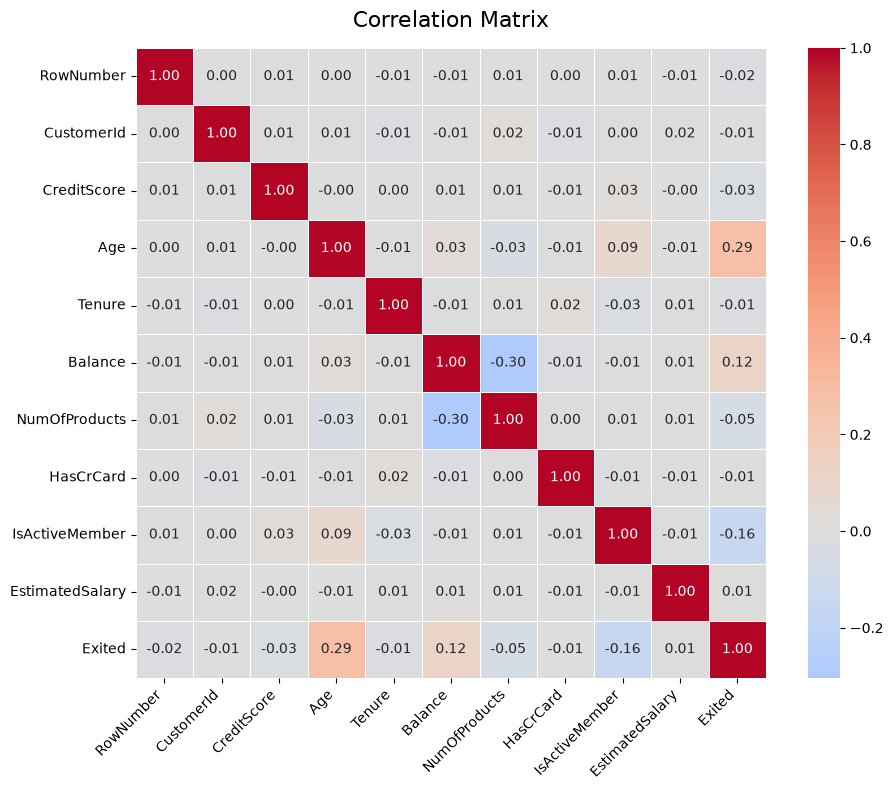

In [142]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
`Age` has the strongest positive correlation with customer churn, followed by `Balance`. In contrast, being an `Active Member` has the strongest negative correlation with churn, indicating that active customers are less likely to leave.

# 3. Data Preprocessing

## 3.1 Remove unnecessary columns

In [143]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3.2 Encoding categorical columns

In [144]:
df = pd.get_dummies(
    df,
    ["Geography", "Gender"],
    dtype=int,
    drop_first=True
)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


## 3.3 Create X and y Data Frames

In [145]:
X = df.drop(columns="Exited")
y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)
